# Phase 2 — Notebook 08 · Stage 2.3 (planning §Stage 2.6) · LOSO across 6 balanced sessions

**Why this notebook exists.** Notebook 07 ran *pooled GroupKFold* on the 6 balanced sessions — neurons from all sessions appear in both train and test, just with disjoint identities. This notebook does the harder cross-session test: **Leave-One-Session-Out (LOSO)** — for each held-out session, train on the *other 5 sessions* and test exclusively on the held-out session's neurons. This is the planning §Stage 2.6 protocol and the first proper test of cross-session generalisation in Phase 2.

**What LOSO tests that pooled GKF does not.** Each session has its own acquisition characteristics: depth-dependent brightness, baseline offset, neuropil contamination, motion-correction quality, gain. A hash-aware Design B model trained on pooled GKF can in principle exploit session-specific shortcuts because it sees *some* neurons from every session at training time. LOSO removes this — the model sees zero neurons from the test session during training, so any cross-session bal-acc must come from layer signal that *generalises across scans*, not from session-specific structure.

**Stage scope (planning §Stage 2.6):**

* Same 6 four-class balanced sessions as NB 07: `5_6, 5_7, 6_2, 6_4, 6_6, 6_7`.
* Same consistent-only neurons (mismatch-removed).
* **6 fits** — one per held-out session. Train = 5 sessions, val = stratified 15% of training neurons (grouped, no leakage), test = held-out session.
* Primary architecture: **Design B + hash embedding + attention pooling** (matching NB 07 primary).
* Secondary architecture (gated by `RUN_MEAN_POOL`): **Design B + hash embedding + mean pooling**.

**Three-way comparison (the reading):**

| | what is held out | what is shared train↔test |
|---|---|---|
| NB 04 within-session 5_6 | a fold of 5_6 neurons | session 5_6 acquisition characteristics |
| NB 07 pooled GKF · 6 sessions | a fold of pooled neurons | every session is in both train and test |
| **NB 08 LOSO · 6 sessions** | **all neurons of one session** | **only the layer signal that transfers across scans** |

Expected ordering: LOSO ≤ pooled GKF ≤ within-session. The *gap* LOSO − pooled GKF is the cross-session penalty. A small gap means the model generalises; a large gap means session-specific structure was doing most of the work.

**Per-class reading.** Class composition varies by session (NB 07 §1 showed e.g. session 6_6 has only 24 L4 neurons). Per-held-out-session per-class recall is the most informative table in this notebook; it tells us which sessions are hard and *which classes* fail to transfer.

**Methodological contract (binding):**

1. Same population, same E1 build, same hash vocabulary, same architecture as NB 07.
2. **Val-set construction.** For each LOSO fit, the val set is a stratified random subset of the training neurons (15%, stratified by layer, grouped — i.e. by `nucleus_id`, no neuron in both train and val). Same `seed = SEED + fit_index` strategy.
3. **Loss.** Inverse-frequency CE on training neurons only (matches NB 04, NB 07; NB 06 showed CB does not help).
4. **Same hyperparameters** as NB 07 (MAX_EPOCHS=50, PATIENCE=8, BATCH_SIZE=32). The training set is roughly the same size as NB 07's GKF train fold (~3,400 neurons) so per-fit compute is comparable: ~20–40 min/fit on MPS, ~2–3 hours total for 6 fits with one pool.
5. **Overfitting guards** as in NB 07: best-epoch distribution, val−test gap, per-class recall stability across the 6 LOSO fits.

Outputs: `data/processed/results/phase2_stage2_3_loso_balanced.parquet` (per held-out-session row + summary, both pools when `RUN_MEAN_POOL=True`).

## 0 · Environment

In [1]:
import os, sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import PROCESSED_RESULTS_DIR
from src.data.loaders import load_working_pop
from src.features.raw_traces import (
    remove_mismatch_neurons,
    build_pooled_e1,
    MAX_TRACE_LEN,
    load_oracle_hashes,
)
from src.models.cnn import LAYER_CLASSES
from src.models.cnn_deepsets import (
    HashAwareDeepSetsTraceCNN,
    build_e1_neuron_tensors_with_hashes,
    train_design_b_hash_fold,
    predict_neuron_proba_hash,
    neuron_score_design_b,
)
from src.eval.cnn_eval import save_results, make_result_row

warnings.filterwarnings('ignore', category=UserWarning)

BALANCED_SESSIONS = ['5_6', '5_7', '6_2', '6_4', '6_6', '6_7']
SEED         = 42
VAL_FRACTION = 0.15            # stratified val subset of training neurons
MAX_EPOCHS   = 50
PATIENCE     = 8
BATCH_SIZE   = 32
TRACE_EMBED  = 64
HASH_EMBED   = 16
ROW_HIDDEN   = 64
HEAD_HIDDEN  = 64
DROPOUT      = 0.25

RUN_ATTENTION_POOL = True       # primary
RUN_MEAN_POOL      = False      # secondary; flip to True if time permits

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device         : {DEVICE}')
print(f'Sessions in pool: {BALANCED_SESSIONS}')
print(f'CV protocol    : LOSO (held out = each session, in turn)')
print(f'Val construction: stratified random {VAL_FRACTION:.0%} of training neurons (grouped)')
print(f'Architectures  : attention_pool={RUN_ATTENTION_POOL}, mean_pool={RUN_MEAN_POOL}')
print(f'Training caps  : max_epochs={MAX_EPOCHS}, patience={PATIENCE}, batch_size={BATCH_SIZE}')
print(f'Seed strategy  : SEED + fit_index (one fit per held-out session)')

Device         : mps
Sessions in pool: ['5_6', '5_7', '6_2', '6_4', '6_6', '6_7']
CV protocol    : LOSO (held out = each session, in turn)
Val construction: stratified random 15% of training neurons (grouped)
Architectures  : attention_pool=True, mean_pool=False
Training caps  : max_epochs=50, patience=8, batch_size=32
Seed strategy  : SEED + fit_index (one fit per held-out session)


## 1 · Population & pooled E1 dataset (same as NB 07)

In [2]:
units_raw = load_working_pop()
units_clean, mismatch_report = remove_mismatch_neurons(units_raw, verbose=False)
df_pool = build_pooled_e1(BALANCED_SESSIONS, units_clean, verbose=True)

# Drop any neuron with incomplete oracle coverage (set-tensor build needs uniform 116)
cov = df_pool.groupby('nucleus_id')['condition_hash'].nunique()
incomplete = cov[cov < 116].index.tolist()
if incomplete:
    print(f'\n⚠️  Dropping {len(incomplete)} neurons with incomplete oracle coverage.')
    df_pool = df_pool[~df_pool['nucleus_id'].isin(incomplete)].reset_index(drop=True)

n_neurons = df_pool['nucleus_id'].nunique()
print(f'\nFinal pooled E1: {n_neurons} neurons × 116 hashes = {len(df_pool):,} rows')
print(f'\nPer-session per-layer composition (the LOSO test set sizes):')
neurons_df = df_pool[['nucleus_id', 'layer_label', 'session_key']].drop_duplicates().reset_index(drop=True)
table = neurons_df.groupby(['session_key', 'layer_label']).size().unstack(fill_value=0)
table['total'] = table.sum(axis=1)
print(table.to_string())

Pooling 6 sessions: ['5_6', '5_7', '6_2', '6_4', '6_6', '6_7']
  Population (mismatch-clean): 4257 neurons
session_key
5_6    685
5_7    696
6_2    734
6_4    824
6_6    606
6_7    712

  Pooled E1 rows: 493,812
  Neurons with data: 4,257
  Oracle coverage per neuron: min=116 median=116 max=116

  Per-session row count:
session_key
5_6    79460
5_7    80736
6_2    85144
6_4    95584
6_6    70296
6_7    82592

Final pooled E1: 4257 neurons × 116 hashes = 493,812 rows

Per-session per-layer composition (the LOSO test set sizes):
layer_label  L2/3   L4   L5  L6  total
session_key                           
5_6           151  249  189  96    685
5_7           184  284  147  81    696
6_2           268  280  153  33    734
6_4           452  122  200  50    824
6_6           401   24  152  29    606
6_7           453   52  192  15    712


## 2 · Hash vocabulary

In [3]:
oracle_hashes, oracle_by_family = load_oracle_hashes()
HASH_VOCAB = sorted(oracle_hashes)
N_HASHES   = len(HASH_VOCAB)
assert N_HASHES == 116
print(f'Hash vocabulary: {N_HASHES} oracle hashes')

Hash vocabulary: 116 oracle hashes


## 3 · Pack pooled E1 into per-neuron set-tensors

Same helper as NB 07. We additionally build a `session_of` array (length `N_neurons`) so the LOSO loop can directly select test/train indices by session.

In [4]:
X, mask, y_str, nids, hash_ids, hash_vocab = build_e1_neuron_tensors_with_hashes(
    df_pool, pad_to=MAX_TRACE_LEN, hash_vocab=HASH_VOCAB,
)
assert hash_vocab == HASH_VOCAB
session_lookup = neurons_df.set_index('nucleus_id')['session_key'].to_dict()
session_of = np.array([session_lookup[int(n)] for n in nids])

print(f'X        : {X.shape}  dtype={X.dtype}  (~{X.nbytes / 1e9:.2f} GB)')
print(f'mask     : valid_frac={mask.sum() / np.prod(mask.shape):.3f}')
print(f'session_of distribution:')
for s in BALANCED_SESSIONS:
    print(f'  {s}: {(session_of == s).sum()} neurons')

X        : (4257, 116, 113)  dtype=float32  (~0.22 GB)
mask     : valid_frac=0.722
session_of distribution:
  5_6: 685 neurons
  5_7: 696 neurons
  6_2: 734 neurons
  6_4: 824 neurons
  6_6: 606 neurons
  6_7: 712 neurons


## 4 · Per-LOSO-fit runner — train hash-aware Design B with selectable pool

For each held-out session $s$:

1. `test_idx` = neurons in session $s$.
2. `train_pool_idx` = neurons in the other 5 sessions.
3. `val_idx` = stratified random `VAL_FRACTION` of `train_pool_idx`, stratified by layer (so val has all 4 classes), seeded by `SEED + fit_index`.
4. `train_idx` = `train_pool_idx \ val_idx`.

The architecture, optimizer, scheduler, early-stopping criterion, and overfitting-tracking are identical to NB 07.

In [5]:
def stratified_val_split(train_indices, fit_seed, val_fraction=VAL_FRACTION):
    """Stratified-by-layer random val split of training neurons (no leakage:
    train and val are disjoint sets of nucleus_ids by construction since we
    operate on per-neuron indices)."""
    rng = np.random.default_rng(fit_seed)
    val_picks = []
    for c in LAYER_CLASSES:
        cls_idx = train_indices[y_str[train_indices] == c]
        if len(cls_idx) == 0:
            continue
        n_val = max(1, int(round(len(cls_idx) * val_fraction)))
        if n_val >= len(cls_idx):
            n_val = max(1, len(cls_idx) - 1)    # leave at least 1 train neuron in this class
        val_picks.append(rng.choice(cls_idx, size=n_val, replace=False))
    val_idx   = np.sort(np.concatenate(val_picks))
    train_idx = np.setdiff1d(train_indices, val_idx, assume_unique=False)
    return train_idx, val_idx

def run_one_loso(test_session: str, fit_index: int, pool: str,
                  seed: int = SEED, verbose: bool = False):
    test_idx       = np.where(session_of == test_session)[0]
    train_pool_idx = np.where(session_of != test_session)[0]
    train_idx, val_idx = stratified_val_split(
        train_pool_idx, fit_seed=seed + fit_index + 1000, val_fraction=VAL_FRACTION,
    )

    # Leakage assertion (no neuron in two splits)
    assert (not (set(train_idx) & set(val_idx))) and (not (set(train_idx) & set(test_idx))) \
        and (not (set(val_idx) & set(test_idx))), 'neuron leakage detected'

    X_tr, M_tr, y_tr = X[train_idx], mask[train_idx], y_str[train_idx]
    X_va, M_va, y_va = X[val_idx],   mask[val_idx],   y_str[val_idx]
    X_te, M_te, y_te = X[test_idx],  mask[test_idx],  y_str[test_idx]

    if verbose:
        print(f'    train: {len(train_idx)}  val: {len(val_idx)}  test: {len(test_idx)}')
        print(f'    train per-class: ' + ' '.join(f'{c}={(y_tr==c).sum()}' for c in LAYER_CLASSES))
        print(f'    test  per-class: ' + ' '.join(f'{c}={(y_te==c).sum()}' for c in LAYER_CLASSES))

    model, history = train_design_b_hash_fold(
        X_tr, M_tr, y_tr,
        X_va, M_va, y_va,
        hash_ids=hash_ids,
        n_hashes=N_HASHES,
        in_channels=1, n_classes=4,
        trace_embed=TRACE_EMBED, hash_embed=HASH_EMBED,
        row_hidden=ROW_HIDDEN, head_hidden=HEAD_HIDDEN,
        dropout=DROPOUT, kernel_size=5,
        pool=pool,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS, patience=PATIENCE,
        lr=1e-3, weight_decay=1e-4,
        seed=seed + fit_index,
        device=DEVICE,
        verbose=verbose,
    )

    # Test inference
    test_probs = predict_neuron_proba_hash(
        model, X_te, hash_ids, mask=M_te,
        batch_size=BATCH_SIZE, device=DEVICE,
    )
    score = neuron_score_design_b(y_te, test_probs, classes=np.array(LAYER_CLASSES))

    # Val inference (post-best-state restore, for the val−test gap diagnostic)
    val_probs = predict_neuron_proba_hash(
        model, X_va, hash_ids, mask=M_va,
        batch_size=BATCH_SIZE, device=DEVICE,
    )
    val_score = neuron_score_design_b(y_va, val_probs, classes=np.array(LAYER_CLASSES))

    score['test_session']        = test_session
    score['n_test']              = len(test_idx)
    score['n_train']             = len(train_idx)
    score['n_val']               = len(val_idx)
    score['val_bal_acc']         = val_score['balanced_accuracy']
    score['val_minus_test_gap']  = val_score['balanced_accuracy'] - score['balanced_accuracy']
    score['best_epoch']          = int(np.argmax([h['val_bal_acc'] for h in history])) + 1
    score['n_epochs_run']        = len(history)
    score['final_train_loss']    = float(history[-1]['train_loss'])
    return score, history

print('LOSO per-fit runner ready.')

LOSO per-fit runner ready.


## 5 · Run all 6 LOSO fits — primary architecture (attention pool)

One fit per held-out session. Compute: ~20–40 min/fit on MPS, ~2–3 hours total.

In [6]:
results   = {pk: [] for pk in ['attention', 'mean']}
histories = {pk: [] for pk in ['attention', 'mean']}

if RUN_ATTENTION_POOL:
    print(f'\n────────  LOSO · attention pool · {len(BALANCED_SESSIONS)} balanced sessions  ────────')
    t0 = time.time()
    for i, test_sess in enumerate(BALANCED_SESSIONS):
        ti = time.time()
        score, hist = run_one_loso(test_sess, fit_index=i, pool='attention',
                                    seed=SEED, verbose=False)
        score['fit_index'] = i
        results['attention'].append(score)
        histories['attention'].append(hist)
        ba  = score['balanced_accuracy']
        f1  = score['macro_f1']
        pcr = score['per_class_recall']
        print(f'  held out {test_sess} | n_test={score["n_test"]:4d} | bal_acc={ba:.4f} '
              f'(val {score["val_bal_acc"]:.4f}, gap {score["val_minus_test_gap"]:+.4f}) '
              f'| F1={f1:.3f} | best_ep={score["best_epoch"]:>2d}/{score["n_epochs_run"]} '
              f'| recall: ' + ' '.join(f'{c}={pcr[c]:.2f}' for c in LAYER_CLASSES)
              + f'  ({time.time() - ti:.1f}s)')
    print(f'\nAttention pool total time: {(time.time() - t0) / 60:.1f} min')


────────  LOSO · attention pool · 6 balanced sessions  ────────
  held out 5_6 | n_test= 685 | bal_acc=0.5557 (val 0.5681, gap +0.0124) | F1=0.524 | best_ep=10/18 | recall: L2/3=0.25 L4=0.39 L5=0.64 L6=0.94  (886.9s)
  held out 5_7 | n_test= 696 | bal_acc=0.5632 (val 0.5634, gap +0.0003) | F1=0.497 | best_ep=10/18 | recall: L2/3=0.07 L4=0.67 L5=0.57 L6=0.95  (2345.6s)
  held out 6_2 | n_test= 734 | bal_acc=0.5709 (val 0.6080, gap +0.0370) | F1=0.548 | best_ep=36/44 | recall: L2/3=0.35 L4=0.45 L5=0.73 L6=0.76  (712.6s)
  held out 6_4 | n_test= 824 | bal_acc=0.5267 (val 0.5673, gap +0.0407) | F1=0.367 | best_ep= 8/16 | recall: L2/3=0.04 L4=0.72 L5=0.69 L6=0.66  (260.2s)
  held out 6_6 | n_test= 606 | bal_acc=0.4928 (val 0.5913, gap +0.0985) | F1=0.364 | best_ep=22/30 | recall: L2/3=0.22 L4=0.38 L5=0.48 L6=0.90  (287.0s)
  held out 6_7 | n_test= 712 | bal_acc=0.4209 (val 0.5982, gap +0.1773) | F1=0.316 | best_ep=26/34 | recall: L2/3=0.34 L4=0.23 L5=0.38 L6=0.73  (302.3s)

Attention pool 

## 6 · Optional — mean pool secondary architecture

In [7]:
if RUN_MEAN_POOL:
    print(f'\n────────  LOSO · mean pool · {len(BALANCED_SESSIONS)} balanced sessions  ────────')
    t0 = time.time()
    for i, test_sess in enumerate(BALANCED_SESSIONS):
        ti = time.time()
        score, hist = run_one_loso(test_sess, fit_index=i, pool='mean',
                                    seed=SEED, verbose=False)
        score['fit_index'] = i
        results['mean'].append(score)
        histories['mean'].append(hist)
        ba  = score['balanced_accuracy']
        f1  = score['macro_f1']
        pcr = score['per_class_recall']
        print(f'  held out {test_sess} | n_test={score["n_test"]:4d} | bal_acc={ba:.4f} '
              f'(val {score["val_bal_acc"]:.4f}, gap {score["val_minus_test_gap"]:+.4f}) '
              f'| F1={f1:.3f} | best_ep={score["best_epoch"]:>2d}/{score["n_epochs_run"]} '
              f'| recall: ' + ' '.join(f'{c}={pcr[c]:.2f}' for c in LAYER_CLASSES)
              + f'  ({time.time() - ti:.1f}s)')
    print(f'\nMean pool total time: {(time.time() - t0) / 60:.1f} min')
else:
    print('Mean pool skipped (RUN_MEAN_POOL=False). Re-run §5 with RUN_MEAN_POOL=True if needed.')

Mean pool skipped (RUN_MEAN_POOL=False). Re-run §5 with RUN_MEAN_POOL=True if needed.


## 7 · Summary across the 6 held-out sessions

Mean ± SD across the 6 LOSO fits (one per held-out session). Mean is the **macro-average across sessions**, NOT a row-level mean — every session contributes equally regardless of its size, which is the right summary for cross-session generalisation.

In [8]:
def summarise(scores):
    if not scores: return None
    bas = np.array([s['balanced_accuracy'] for s in scores])
    f1s = np.array([s['macro_f1']          for s in scores])
    pcr = {c: np.array([s['per_class_recall'][c] for s in scores]) for c in LAYER_CLASSES}
    return {
        'bal_acc_mean':  bas.mean(), 'bal_acc_std':  bas.std(ddof=0),
        'macro_f1_mean': f1s.mean(), 'macro_f1_std': f1s.std(ddof=0),
        **{f'recall_{c}_mean': np.nanmean(pcr[c]) for c in LAYER_CLASSES},
        **{f'recall_{c}_std':  np.nanstd (pcr[c]) for c in LAYER_CLASSES},
    }

summaries = {pk: summarise(results[pk]) for pk in ['attention', 'mean']}

rows = []
labels = {'attention': 'LOSO · attention pool', 'mean': 'LOSO · mean pool'}
for pk in ['attention', 'mean']:
    s = summaries[pk]
    if s is None: continue
    rows.append({
        'model':    labels[pk],
        'bal_acc':  f"{s['bal_acc_mean']:.4f} ± {s['bal_acc_std']:.4f}",
        'macro_F1': f"{s['macro_f1_mean']:.4f} ± {s['macro_f1_std']:.4f}",
        'L2/3':     f"{s['recall_L2/3_mean']:.3f} ± {s['recall_L2/3_std']:.3f}",
        'L4':       f"{s['recall_L4_mean']:.3f} ± {s['recall_L4_std']:.3f}",
        'L5':       f"{s['recall_L5_mean']:.3f} ± {s['recall_L5_std']:.3f}",
        'L6':       f"{s['recall_L6_mean']:.3f} ± {s['recall_L6_std']:.3f}",
    })
summary_df = pd.DataFrame(rows).set_index('model') if rows else pd.DataFrame()
print(f'Stage 2.3 LOSO (planning §Stage 2.6) · 6 balanced sessions · macro-average across held-out\n')
print(summary_df.to_string() if not summary_df.empty else '(no results — set RUN_ATTENTION_POOL or RUN_MEAN_POOL to True)')

Stage 2.3 LOSO (planning §Stage 2.6) · 6 balanced sessions · macro-average across held-out

                               bal_acc         macro_F1           L2/3             L4             L5             L6
model                                                                                                              
LOSO · attention pool  0.5217 ± 0.0522  0.4359 ± 0.0897  0.211 ± 0.123  0.473 ± 0.170  0.580 ± 0.122  0.823 ± 0.111


## 8 · Per-held-out-session table (the headline)

For each of the 6 held-out sessions, the bal-acc / macro-F1 / per-class recall directly measures how well the model trained on the *other 5 sessions* generalises *to that session's neurons*.

Sessions 6_6 and 6_7 have very few L4 neurons (24 and 52 in the clean population) — per-class recall on L4 may be unstable and is reported as informational, not a primary metric.

In [9]:
for pk in ['attention', 'mean']:
    if not results[pk]: continue
    rows = []
    for s in results[pk]:
        pcr = s['per_class_recall']
        rows.append({
            'held_out':         s['test_session'],
            'n_test':           s['n_test'],
            'n_train':          s['n_train'],
            'bal_acc':          f'{s["balanced_accuracy"]:.4f}',
            'macro_F1':         f'{s["macro_f1"]:.4f}',
            'L2/3':             f'{pcr["L2/3"]:.3f}',
            'L4':               f'{pcr["L4"]:.3f}',
            'L5':               f'{pcr["L5"]:.3f}',
            'L6':               f'{pcr["L6"]:.3f}',
            'val_bal_acc':      f'{s["val_bal_acc"]:.3f}',
            'val_minus_test':   f'{s["val_minus_test_gap"]:+.3f}',
            'best_ep/total':    f'{s["best_epoch"]}/{s["n_epochs_run"]}',
        })
    print(f'\n── LOSO per held-out session · pool={pk} ──\n')
    print(pd.DataFrame(rows).set_index('held_out').to_string())


── LOSO per held-out session · pool=attention ──

          n_test  n_train bal_acc macro_F1   L2/3     L4     L5     L6 val_bal_acc val_minus_test best_ep/total
held_out                                                                                                       
5_6          685     3036  0.5557   0.5238  0.252  0.394  0.640  0.938       0.568         +0.012         10/18
5_7          696     3027  0.5632   0.4966  0.065  0.665  0.571  0.951       0.563         +0.000         10/18
6_2          734     2994  0.5709   0.5480  0.347  0.454  0.725  0.758       0.608         +0.037         36/44
6_4          824     2918  0.5267   0.3673  0.035  0.721  0.690  0.660       0.567         +0.041          8/16
6_6          606     3104  0.4928   0.3639  0.219  0.375  0.480  0.897       0.591         +0.099         22/30
6_7          712     3014  0.4209   0.3161  0.344  0.231  0.375  0.733       0.598         +0.177         26/34


## 9 · Overfitting / generalisation diagnostics

Same three quantities as NB 07 §9, but now interpreted under cross-session conditions:

* `val_minus_test_gap` — val draws from the same 5 training sessions as train, while test is the held-out session. A consistently positive gap therefore signals *cross-session structure-shift*: the model fits the training-session distribution but not the test-session distribution. This is exactly the cross-session penalty.
* `best_epoch` — early peaks (< 5 epochs) hint that the model latches onto session-specific shortcuts and then degrades. Late peaks (close to `MAX_EPOCHS`) hint the budget may be too small.
* `final_train_loss` — read alongside the gap; very low train loss + large gap = memorising training sessions.

In [10]:
for pk in ['attention', 'mean']:
    if not results[pk]: continue
    gaps = np.array([s['val_minus_test_gap'] for s in results[pk]])
    epochs = np.array([s['best_epoch'] for s in results[pk]])
    msg = (f'[{pk}] mean val−test gap = {gaps.mean():+.3f} ± {gaps.std(ddof=0):.3f}; '
           f'mean best_epoch = {epochs.mean():.1f}')
    if gaps.mean() > 0.07:
        msg += '   → ⚠️  large positive gap = strong cross-session shift / poor LOSO generalisation'
    elif gaps.mean() > 0.03:
        msg += '   → moderate cross-session shift'
    elif gaps.mean() > -0.03:
        msg += '   → small gap, the model generalises across sessions in this regime'
    else:
        msg += '   → unusual: val < test (check val construction)'
    if epochs.mean() < 5:
        msg += f'\n         ⚠️  best_epoch averages {epochs.mean():.1f} — peaks very early'
    print(msg)

[attention] mean val−test gap = +0.061 ± 0.061; mean best_epoch = 18.7   → moderate cross-session shift


## 10 · Three-way comparison: NB 04 within-session 5_6 vs NB 07 pooled GKF vs NB 08 LOSO

Loads NB 04's within-session 5_6 summaries and NB 07's pooled GKF summaries. The expected ordering is **NB 04 > NB 07 > NB 08** for any given pool kind:

* NB 04 → NB 07 gap = the cost of training on more diverse data (the prior change should *help* L2/3, *hurt* L6).
* NB 07 → NB 08 gap = the cost of *not seeing the test session at training time*. This is the cross-session penalty.

If NB 08 ≈ NB 07, the model genuinely learnt session-invariant layer signal. If NB 08 ≪ NB 07, NB 07's apparent gain over NB 04 was carried by session-specific information that LOSO removes.

In [11]:
rows = []

# NB 04 — within-session 5_6
nb04_path = Path('data/processed/results/phase2_stage2_2a_hash_aware_design_b.parquet')
nb04_models = {
    'attention': 'HashAwareDeepSetsCNN_E1_raw_identity_attnpool',
    'mean':      'HashAwareDeepSetsCNN_E1_raw_identity_meanpool',
}
if nb04_path.exists():
    df04 = pd.read_parquet(nb04_path)
    for pk in ['attention', 'mean']:
        sub = df04[(df04['model_name'] == nb04_models[pk]) &
                    (df04['fold_or_session'] == '5_6_summary')]
        if len(sub):
            r = sub.iloc[0]
            rows.append({
                'context':  f'NB 04 · within 5_6 · {pk} pool',
                'bal_acc':  f'{r["balanced_accuracy"]:.4f}',
                'macro_F1': f'{r["macro_f1"]:.4f}',
                'L2/3':     f'{r["recall_L23"]:.3f}',
                'L4':       f'{r["recall_L4"]:.3f}',
                'L5':       f'{r["recall_L5"]:.3f}',
                'L6':       f'{r["recall_L6"]:.3f}',
            })

# NB 07 — pooled GKF on 6 sessions
nb07_path = Path('data/processed/results/phase2_stage2_3_pooled_gkf_balanced.parquet')
nb07_models = {
    'attention': 'HashAwareDeepSetsCNN_E1_raw_identity_attnpool_pooled_GKF',
    'mean':      'HashAwareDeepSetsCNN_E1_raw_identity_meanpool_pooled_GKF',
}
if nb07_path.exists():
    df07 = pd.read_parquet(nb07_path)
    for pk in ['attention', 'mean']:
        sub = df07[(df07['model_name'] == nb07_models[pk]) &
                    (df07['fold_or_session'] == 'pool_summary')]
        if len(sub):
            r = sub.iloc[0]
            rows.append({
                'context':  f'NB 07 · pooled GKF · {pk} pool',
                'bal_acc':  f'{r["balanced_accuracy"]:.4f}',
                'macro_F1': f'{r["macro_f1"]:.4f}',
                'L2/3':     f'{r["recall_L23"]:.3f}',
                'L4':       f'{r["recall_L4"]:.3f}',
                'L5':       f'{r["recall_L5"]:.3f}',
                'L6':       f'{r["recall_L6"]:.3f}',
            })
else:
    print(f'(NB 07 results not yet at {nb07_path}; comparison skipped for that row.)')

# NB 08 — this notebook's LOSO
for pk in ['attention', 'mean']:
    if results[pk]:
        s = summaries[pk]
        rows.append({
            'context':  f'NB 08 · LOSO · {pk} pool (THIS NB)',
            'bal_acc':  f'{s["bal_acc_mean"]:.4f}',
            'macro_F1': f'{s["macro_f1_mean"]:.4f}',
            'L2/3':     f'{s["recall_L2/3_mean"]:.3f}',
            'L4':       f'{s["recall_L4_mean"]:.3f}',
            'L5':       f'{s["recall_L5_mean"]:.3f}',
            'L6':       f'{s["recall_L6_mean"]:.3f}',
        })

print('Three-way comparison · same architecture, different splits:\n')
print(pd.DataFrame(rows).set_index('context').to_string())
print()
print('Reading guide:')
print('  NB 04 → NB 07 gap : effect of pooling more data (helps majority L2/3, hurts minority L6)')
print('  NB 07 → NB 08 gap : the cross-session penalty (this is the claim test)')
print('  Per-class: which classes survive the LOSO transition tells you what generalises.')

Three-way comparison · same architecture, different splits:

                                        bal_acc macro_F1   L2/3     L4     L5     L6
context                                                                             
NB 04 · within 5_6 · attention pool      0.5685   0.5252  0.060  0.648  0.638  0.927
NB 04 · within 5_6 · mean pool           0.5247   0.4689  0.169  0.439  0.606  0.886
NB 07 · pooled GKF · attention pool      0.5589   0.4693  0.168  0.553  0.614  0.900
NB 08 · LOSO · attention pool (THIS NB)  0.5217   0.4359  0.211  0.473  0.580  0.823

Reading guide:
  NB 04 → NB 07 gap : effect of pooling more data (helps majority L2/3, hurts minority L6)
  NB 07 → NB 08 gap : the cross-session penalty (this is the claim test)
  Per-class: which classes survive the LOSO transition tells you what generalises.


## 11 · Paired per-session comparison: NB 08 LOSO vs NB 07 pooled GKF

NB 07 §10 saved per-session test bal-acc *within* its pooled GKF folds (each session contributes some neurons to each fold's test set). NB 08 holds entire sessions out as test. Pairing both per-session gives the cleanest cross-session-penalty read **per session**: where does each session lose accuracy when it is fully held out?

In [12]:
if not nb07_path.exists():
    print('NB 07 parquet missing — skipping paired per-session comparison.')
else:
    df07 = pd.read_parquet(nb07_path)
    for pk in ['attention', 'mean']:
        if not results[pk]: continue
        # NB 07 per-fold rows include per_session_bal_acc=... in the notes string
        sub07 = df07[(df07['model_name'] == nb07_models[pk]) &
                      (df07['fold_or_session'].str.startswith('pool_fold'))].copy()
        if len(sub07) == 0: continue
        # Parse per_session string: '5_6=0.512/n=137;...'
        per_session_07 = {s: [] for s in BALANCED_SESSIONS}
        for _, r in sub07.iterrows():
            for tok in str(r['notes']).split(';'):
                tok = tok.strip()
                if '=' in tok and '/n=' in tok:
                    sess, rest = tok.split('=', 1)
                    if sess in per_session_07:
                        try:
                            ba_str = rest.split('/')[0]
                            per_session_07[sess].append(float(ba_str))
                        except (ValueError, IndexError):
                            pass
        rows = []
        for s in results[pk]:
            sess = s['test_session']
            ba_07_arr = np.array([v for v in per_session_07.get(sess, []) if not np.isnan(v)])
            ba_07_mean = float(ba_07_arr.mean()) if len(ba_07_arr) else float('nan')
            ba_08      = s['balanced_accuracy']
            gap        = ba_07_mean - ba_08 if not np.isnan(ba_07_mean) else float('nan')
            rows.append({
                'session':                    sess,
                'NB 07 within-pool bal_acc':  f'{ba_07_mean:.3f}' if not np.isnan(ba_07_mean) else 'nan',
                'NB 08 LOSO bal_acc':         f'{ba_08:.3f}',
                'cross-session penalty (Δ)':  f'{gap:+.3f}'        if not np.isnan(gap)        else 'nan',
            })
        print(f'\n── Paired per-session · pool={pk} ──\n')
        print(pd.DataFrame(rows).set_index('session').to_string())
        print('\nΔ > 0 = LOSO is worse than within-pool for that session (= the cost of unseen-session test).')


── Paired per-session · pool=attention ──

        NB 07 within-pool bal_acc NB 08 LOSO bal_acc cross-session penalty (Δ)
session                                                                       
5_6                           nan              0.556                       nan
5_7                         0.578              0.563                    +0.014
6_2                         0.587              0.571                    +0.016
6_4                         0.539              0.527                    +0.012
6_6                         0.469              0.493                    -0.024
6_7                         0.495              0.421                    +0.074

Δ > 0 = LOSO is worse than within-pool for that session (= the cost of unseen-session test).


## 12 · Plots — per-held-out-session bal-acc, per-class recall, confusion matrices, training curves

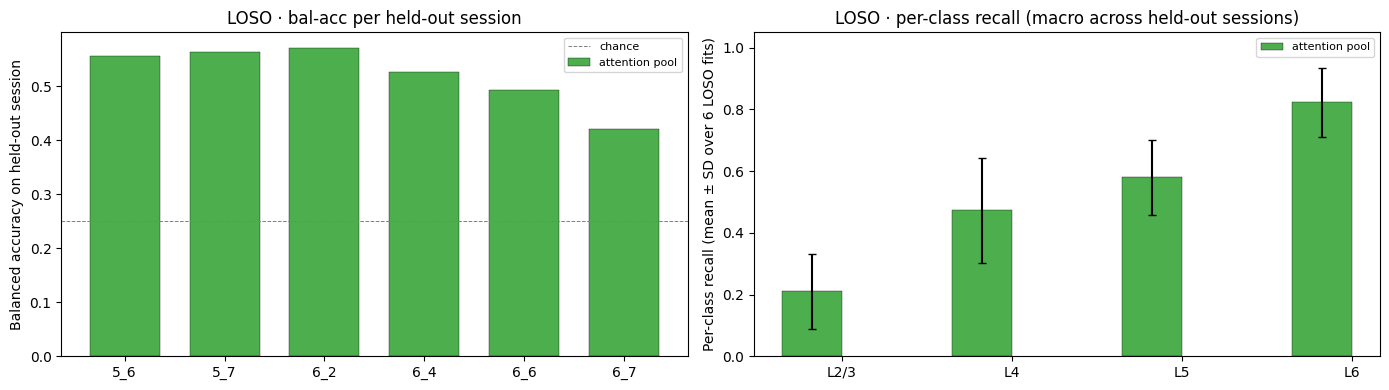

In [13]:
n_pools_run = sum(1 for pk in ['attention','mean'] if results[pk])
if n_pools_run == 0:
    print('No results to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # (a) Bal-acc per held-out session
    ax = axes[0]
    x = np.arange(len(BALANCED_SESSIONS))
    width = 0.35
    for offset, pk, color in [(-width/2, 'attention', 'C2'), (+width/2, 'mean', 'C3')]:
        if not results[pk]: continue
        # Order results by BALANCED_SESSIONS
        ba_by_sess = {s['test_session']: s['balanced_accuracy'] for s in results[pk]}
        bars = [ba_by_sess[s] for s in BALANCED_SESSIONS]
        ax.bar(x + (offset if n_pools_run > 1 else 0),
               bars, width if n_pools_run > 1 else 0.7,
               label=f'{pk} pool', color=color, alpha=0.85, edgecolor='k', linewidth=0.3)
    ax.axhline(0.25, color='gray', ls='--', lw=0.7, label='chance')
    ax.set_xticks(x); ax.set_xticklabels(BALANCED_SESSIONS)
    ax.set_ylabel('Balanced accuracy on held-out session')
    ax.set_title('LOSO · bal-acc per held-out session')
    ax.legend(fontsize=8)

    # (b) Per-class recall (mean ± SD across the 6 LOSO fits)
    ax = axes[1]
    x = np.arange(len(LAYER_CLASSES)); width = 0.35
    for offset, pk, color in [(-width/2, 'attention', 'C2'), (+width/2, 'mean', 'C3')]:
        if not results[pk]: continue
        means = np.array([summaries[pk][f'recall_{c}_mean'] for c in LAYER_CLASSES])
        stds  = np.array([summaries[pk][f'recall_{c}_std']  for c in LAYER_CLASSES])
        ax.bar(x + offset, means, width, yerr=stds, capsize=3, label=f'{pk} pool',
               color=color, alpha=0.85, edgecolor='k', linewidth=0.3)
    ax.set_xticks(x); ax.set_xticklabels(LAYER_CLASSES)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Per-class recall (mean ± SD over 6 LOSO fits)')
    ax.set_title('LOSO · per-class recall (macro across held-out sessions)')
    ax.legend(fontsize=8)

    plt.tight_layout(); plt.show()

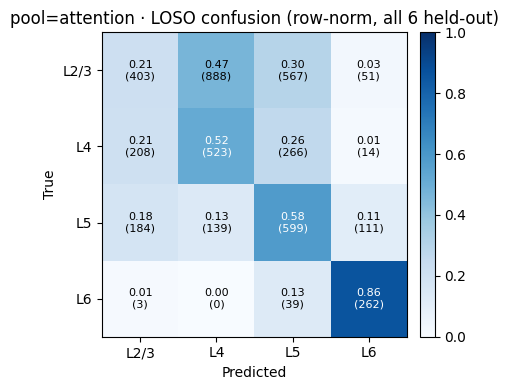

In [14]:
# Confusion matrices summed across the 6 LOSO fits, per pool
pools_with_results = [pk for pk in ['attention','mean'] if results[pk]]
if pools_with_results:
    fig, axes = plt.subplots(1, len(pools_with_results), figsize=(5 * len(pools_with_results), 4),
                              squeeze=False)
    for i, pk in enumerate(pools_with_results):
        ax = axes[0, i]
        Cm = sum(s['confusion_matrix'] for s in results[pk])
        Cn = Cm / Cm.sum(axis=1, keepdims=True).clip(min=1)
        im = ax.imshow(Cn, vmin=0, vmax=1, cmap='Blues')
        for ii in range(Cm.shape[0]):
            for jj in range(Cm.shape[1]):
                ax.text(jj, ii, f'{Cn[ii,jj]:.2f}\n({Cm[ii,jj]})',
                        ha='center', va='center', fontsize=8,
                        color='white' if Cn[ii,jj] > 0.5 else 'black')
        ax.set_xticks(range(len(LAYER_CLASSES))); ax.set_xticklabels(LAYER_CLASSES)
        ax.set_yticks(range(len(LAYER_CLASSES))); ax.set_yticklabels(LAYER_CLASSES)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'pool={pk} · LOSO confusion (row-norm, all 6 held-out)')
        plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    plt.tight_layout(); plt.show()

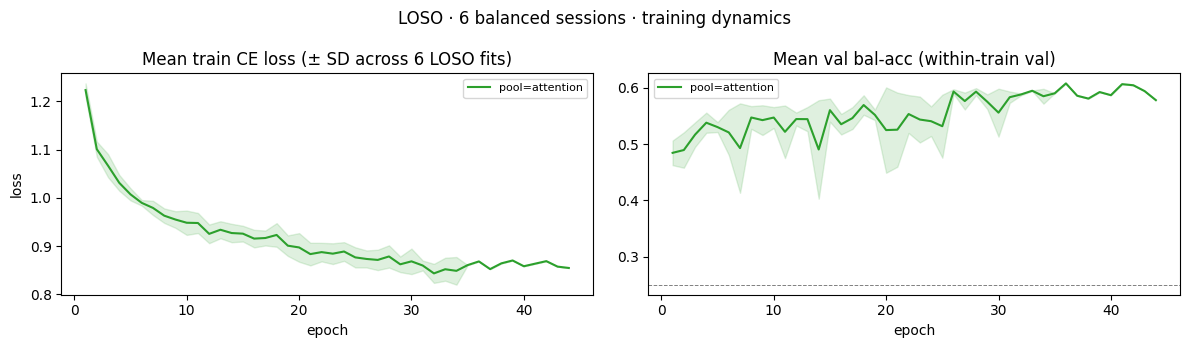

In [15]:
# Training curves (mean ± SD across the 6 LOSO fits), per-pool overlay
if any(results[pk] for pk in ['attention','mean']):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    for pk, color in [('attention', 'C2'), ('mean', 'C3')]:
        if not results[pk]: continue
        hists = histories[pk]
        max_e = max(len(h) for h in hists)
        loss = np.full((len(hists), max_e), np.nan)
        vacc = np.full((len(hists), max_e), np.nan)
        for ii, h in enumerate(hists):
            loss[ii, :len(h)] = [r['train_loss']  for r in h]
            vacc[ii, :len(h)] = [r['val_bal_acc'] for r in h]
        epochs = np.arange(1, max_e + 1)
        axes[0].plot(epochs, np.nanmean(loss, 0), color=color, label=f'pool={pk}')
        axes[0].fill_between(epochs,
                             np.nanmean(loss, 0) - np.nanstd(loss, 0),
                             np.nanmean(loss, 0) + np.nanstd(loss, 0), color=color, alpha=0.15)
        axes[1].plot(epochs, np.nanmean(vacc, 0), color=color, label=f'pool={pk}')
        axes[1].fill_between(epochs,
                             np.nanmean(vacc, 0) - np.nanstd(vacc, 0),
                             np.nanmean(vacc, 0) + np.nanstd(vacc, 0), color=color, alpha=0.15)
    axes[0].set(title='Mean train CE loss (± SD across 6 LOSO fits)', xlabel='epoch', ylabel='loss')
    axes[1].set(title='Mean val bal-acc (within-train val)',           xlabel='epoch')
    axes[1].axhline(0.25, color='gray', ls='--', lw=0.7)
    for ax in axes: ax.legend(fontsize=8)
    plt.suptitle('LOSO · 6 balanced sessions · training dynamics')
    plt.tight_layout(); plt.show()

## 13 · Persist results

In [16]:
MODEL_NAME = {
    'attention': 'HashAwareDeepSetsCNN_E1_raw_identity_attnpool_LOSO',
    'mean':      'HashAwareDeepSetsCNN_E1_raw_identity_meanpool_LOSO',
}

rows = []
for pk in ['attention', 'mean']:
    if not results[pk]: continue
    s_summary = summaries[pk]
    note_base = (f'Stage 2.3 LOSO (planning §Stage 2.6); pool={pk}; '
                 f'sessions={",".join(BALANCED_SESSIONS)}; '
                 f'val_fraction={VAL_FRACTION}; loss=inverse_freq; '
                 f'trace_embed={TRACE_EMBED} hash_embed={HASH_EMBED} '
                 f'row_hidden={ROW_HIDDEN} head_hidden={HEAD_HIDDEN}; '
                 f'n_hashes={N_HASHES}; mismatch removed; padded T={MAX_TRACE_LEN}; '
                 f'masked GAP per trace')
    for s in results[pk]:
        rows.append(make_result_row(
            model_name      = MODEL_NAME[pk],
            input_mode      = 'E1_set_padded_oracle_with_hash_pooled',
            normalization   = 'raw',
            stimulus_family = 'all_padded',
            split_protocol  = 'LOSO_balanced6',
            fold_or_session = f'loso_held_out_{s["test_session"]}',
            seed            = SEED + s['fit_index'],
            score_dict      = s,
            notes           = (note_base + f'; n_train={s["n_train"]}; n_val={s["n_val"]}; '
                                f'n_test={s["n_test"]}; '
                                f'val_minus_test_gap={s["val_minus_test_gap"]:+.4f}; '
                                f'best_epoch={s["best_epoch"]}/{s["n_epochs_run"]}'),
        ))
    rows.append({
        'model_name':        MODEL_NAME[pk],
        'input_mode':        'E1_set_padded_oracle_with_hash_pooled',
        'normalization':     'raw',
        'stimulus_family':   'all_padded',
        'split_protocol':    'LOSO_balanced6',
        'fold_or_session':   'loso_summary',
        'seed':              SEED,
        'n_neurons':         int(np.mean([sc['n_test'] for sc in results[pk]])),
        'balanced_accuracy': float(s_summary['bal_acc_mean']),
        'macro_f1':          float(s_summary['macro_f1_mean']),
        'recall_L23':        float(s_summary['recall_L2/3_mean']),
        'recall_L4':         float(s_summary['recall_L4_mean']),
        'recall_L5':         float(s_summary['recall_L5_mean']),
        'recall_L6':         float(s_summary['recall_L6_mean']),
        'notes':             (f'Stage 2.3 LOSO SUMMARY · pool={pk}; macro-average over 6 held-out '
                              f'sessions; bal_acc_std={s_summary["bal_acc_std"]:.4f}'),
    })

if rows:
    save_results(rows, 'phase2_stage2_3_loso_balanced.parquet')
    print(f'Saved {len(rows)} rows → data/processed/results/phase2_stage2_3_loso_balanced.parquet')
else:
    print('No rows to save (no pool ran). Set RUN_ATTENTION_POOL or RUN_MEAN_POOL to True.')

Saved 7 row(s) → data/processed/results/phase2_stage2_3_loso_balanced.parquet  (total: 7)
Saved 7 rows → data/processed/results/phase2_stage2_3_loso_balanced.parquet


---

### What this notebook does NOT claim

* **No engineered-tier comparison.** Tier-G / Tier-A / multimodal benchmarks are still deferred to the end-of-Phase-2 benchmark notebook. The present LOSO numbers will be paired against the matched Tier G LOSO numbers there.
* **No kinetics claim.** Same as before; requires the temporal control suite on the LOSO winning model — only run if LOSO is genuinely competitive.
* **No claim that holds out beyond the 6 balanced sessions.** Sessions like 9_3 / 9_4 / 9_6 (single-class only) are explicitly excluded; full 13-session LOSO is planning §Stage 2.7.

### How to read the result

Reading guide for §10's three-way table — focus on the **NB 07 → NB 08 gap**:

* **Gap < 0.03 (cross-session penalty negligible)** → the model has learnt session-invariant layer signal. Strong/intermediate Phase-2 claim becomes reachable per planning §11.
* **Gap 0.03–0.07** → the model partially generalises but a meaningful share of NB 07's gain was session-specific. Intermediate claim still possible; Tier G LOSO comparison is decisive.
* **Gap > 0.07** → most of the pool's gain was session-specific. Cross-session generalisation is poor; the trace-CNN is below the planning §11 strong-claim threshold.

Per-class: a clean LOSO often loses one specific class's recall (most likely L6 because the loss heavily up-weights it). Read §11's paired per-session table to localise the loss.

### Next notebook

* If LOSO is competitive (gap < 0.05 vs NB 07) and L2/3 holds → carry this model forward to the **end-of-Phase-2 benchmark notebook**: paired comparison vs Tier G LOSO on the matched 6-session subset; if it beats Tier G, add the temporal control suite (time-shuffled, amplitude-only) under LOSO.
* If LOSO collapses → **stop scaling**. Document the cross-session penalty and the Tier G gap; the trace-CNN is a within-protocol model. The claim should be the planning §11 weak/intermediate one, not the strong one.
* Full 13-session LOSO (planning §Stage 2.7) only if the 6-session LOSO is promising.